In [1]:
# ============================================================
# CELL 1 — SIH26240 SPRING REVIVAL
# Final Clean Notebook Setup
# ============================================================

# Install/ensure required package
!pip -q install pysheds

# ------------------------------------------------------------
# Imports
# ------------------------------------------------------------

import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import rasterio

from scipy.ndimage import (
    uniform_filter,
    distance_transform_edt,
    label
)

from pysheds.grid import Grid

warnings.filterwarnings("ignore")

# ------------------------------------------------------------
# File paths
# ------------------------------------------------------------

V6_PATH = "/content/darjeeling_spring_features_v6_geology (1).csv"
CGWB_PATH = "/content/cgwb_darjeeling_32_springs (1).csv"
DEM_PATH = "/content/darjeeling_merged_dem (1).tif"

# ------------------------------------------------------------
# Check files
# ------------------------------------------------------------

required_files = {
    "V6 spring dataset": V6_PATH,
    "CGWB dataset": CGWB_PATH,
    "DEM": DEM_PATH
}

print("=" * 70)
print("SIH26240 SPRING REVIVAL — FINAL NOTEBOOK")
print("=" * 70)

all_present = True

for name, path in required_files.items():
    exists = os.path.exists(path)
    print(f"{name:25s} : {'✅ FOUND' if exists else '❌ MISSING'}")
    if not exists:
        all_present = False

print("=" * 70)

if all_present:
    print("✅ All required input files are available.")
else:
    print("❌ One or more required files are missing.")

print("\nReady for Cell 2.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.3/62.3 kB 2.2 MB/s eta 0:00:00
SIH26240 SPRING REVIVAL — FINAL NOTEBOOK
V6 spring dataset         : ✅ FOUND
CGWB dataset              : ✅ FOUND
DEM                       : ✅ FOUND
✅ All required input files are available.

Ready for Cell 2.


In [2]:
# ============================================================
# CELL 2 — LOAD & VERIFY FINAL INPUT DATA
# ============================================================

# ------------------------------------------------------------
# Load CSV files
# ------------------------------------------------------------

v6 = pd.read_csv(V6_PATH)
cgwb = pd.read_csv(CGWB_PATH)

# ------------------------------------------------------------
# Load DEM metadata
# ------------------------------------------------------------

with rasterio.open(DEM_PATH) as src:
    dem_width = src.width
    dem_height = src.height
    dem_crs = src.crs
    dem_transform = src.transform
    dem_nodata = src.nodata
    dem_bounds = src.bounds
    dem_resolution = src.res

# ------------------------------------------------------------
# Basic dataset information
# ------------------------------------------------------------

print("=" * 70)
print("V6 SPRING DATASET")
print("=" * 70)

print("Shape:", v6.shape)

print("\nColumns:")
print(v6.columns.tolist())

print("\nMissing values:")
print(v6.isnull().sum())

print("\n" + "=" * 70)
print("CGWB VALIDATION DATASET")
print("=" * 70)

print("Shape:", cgwb.shape)

print("\nColumns:")
print(cgwb.columns.tolist())

print("\nMissing values:")
print(cgwb.isnull().sum())

# ------------------------------------------------------------
# DEM information
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("DEM INFORMATION")
print("=" * 70)

print("Width       :", dem_width)
print("Height      :", dem_height)
print("CRS         :", dem_crs)
print("NoData      :", dem_nodata)
print("Resolution  :", dem_resolution)
print("Bounds      :", dem_bounds)

# ------------------------------------------------------------
# Basic validation
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("BASIC VALIDATION")
print("=" * 70)

assert len(v6) == 100, "V6 dataset should contain 100 springs."
assert len(cgwb) == 32, "CGWB dataset should contain 32 springs."
assert dem_crs is not None, "DEM CRS is missing."

print("✅ V6 dataset contains 100 springs.")
print("✅ CGWB dataset contains 32 validation springs.")
print("✅ DEM CRS is available.")
print("✅ Input integrity check completed.")

print("\nReady for Cell 3.")

V6 SPRING DATASET
Shape: (100, 26)

Columns:
['Sl. No.', 'State', 'District', 'Spring Name', 'Latitude', 'Longitude', 'Elevation', 'pH', 'TDS', 'DEM_Elevation', 'Elevation_Difference', 'DEM_Neighborhood_Median', 'Neighborhood_Difference', 'Elevation_QC', 'Slope', 'Aspect', 'Annual_Rainfall_2023', 'LULC_Code', 'LULC', 'Distance_to_Drainage_m', 'Flow_Accumulation', 'Clay_0_5cm', 'Geology', 'Geology_Code', 'Geology_Source_Sheet', 'Geology_QC']

Missing values:
Sl. No.                      0
State                        0
District                     0
Spring Name                  2
Latitude                     0
Longitude                    0
Elevation                    0
pH                           0
TDS                        100
DEM_Elevation                0
Elevation_Difference         0
DEM_Neighborhood_Median      0
Neighborhood_Difference      0
Elevation_QC                 0
Slope                        0
Aspect                       0
Annual_Rainfall_2023         0
LULC_Code  

In [3]:
# ============================================================
# CELL 3 — FINAL V6 DATA QUALITY CONTROL
# ============================================================

print("=" * 70)
print("FINAL V6 DATA QUALITY CONTROL")
print("=" * 70)

# ------------------------------------------------------------
# 1. UNIQUE SPRING IDs
# ------------------------------------------------------------

print("\n1. SPRING ID CHECK")

duplicate_ids = v6["Sl. No."][v6["Sl. No."].duplicated()].tolist()

print("Total rows:", len(v6))
print("Unique Sl. No.:", v6["Sl. No."].nunique())
print("Duplicate IDs:", duplicate_ids if duplicate_ids else "None")

assert len(v6) == 100
assert v6["Sl. No."].nunique() == 100

# ------------------------------------------------------------
# 2. COORDINATE CHECK
# ------------------------------------------------------------

print("\n2. COORDINATE CHECK")

lat_min = v6["Latitude"].min()
lat_max = v6["Latitude"].max()

lon_min = v6["Longitude"].min()
lon_max = v6["Longitude"].max()

print(f"Latitude range : {lat_min:.6f} to {lat_max:.6f}")
print(f"Longitude range: {lon_min:.6f} to {lon_max:.6f}")

print("Invalid latitude:",
      ((v6["Latitude"] < -90) | (v6["Latitude"] > 90)).sum())

print("Invalid longitude:",
      ((v6["Longitude"] < -180) | (v6["Longitude"] > 180)).sum())

assert ((v6["Latitude"] < -90) | (v6["Latitude"] > 90)).sum() == 0
assert ((v6["Longitude"] < -180) | (v6["Longitude"] > 180)).sum() == 0

# ------------------------------------------------------------
# 3. NUMERIC FEATURE RANGES
# ------------------------------------------------------------

print("\n3. NUMERIC FEATURE RANGES")

numeric_columns = [
    "Elevation",
    "DEM_Elevation",
    "Slope",
    "Aspect",
    "Annual_Rainfall_2023",
    "Distance_to_Drainage_m",
    "Flow_Accumulation",
    "Clay_0_5cm"
]

for col in numeric_columns:

    print(
        f"{col:28s}: "
        f"min={v6[col].min():.3f}, "
        f"max={v6[col].max():.3f}, "
        f"missing={v6[col].isna().sum()}"
    )

# ------------------------------------------------------------
# 4. IMPORTANT CATEGORICAL FEATURES
# ------------------------------------------------------------

print("\n4. CATEGORICAL FEATURE CHECK")

print("\nLULC:")
print(v6["LULC"].value_counts(dropna=False))

print("\nGeology:")
print(v6["Geology"].value_counts(dropna=False))

print("\nElevation QC:")
print(v6["Elevation_QC"].value_counts(dropna=False))

print("\nGeology QC:")
print(v6["Geology_QC"].value_counts(dropna=False))

# ------------------------------------------------------------
# 5. RAINFALL RESOLUTION CHECK
# ------------------------------------------------------------

print("\n5. RAINFALL CHECK")

unique_rainfall = v6["Annual_Rainfall_2023"].nunique()

print("Unique annual rainfall values:", unique_rainfall)
print(
    "Values:",
    sorted(v6["Annual_Rainfall_2023"].dropna().unique())
)

# This is a documented pilot limitation, not an error.
print(
    "\nNote: rainfall is spatially coarse/repeated in the pilot "
    "dataset and will be treated as a supporting feature."
)

# ------------------------------------------------------------
# 6. TDS CHECK
# ------------------------------------------------------------

print("\n6. TDS CHECK")

tds_missing = v6["TDS"].isna().sum()

print("Missing TDS values:", tds_missing, "/", len(v6))

if tds_missing == len(v6):
    print("✅ TDS excluded from final modelling because all values are missing.")
else:
    print("TDS contains some observed values.")

# ------------------------------------------------------------
# 7. SPRING NAME CHECK
# ------------------------------------------------------------

print("\n7. SPRING NAME CHECK")

missing_names = v6[v6["Spring Name"].isna()]

print("Missing Spring Names:", len(missing_names))

if len(missing_names) > 0:
    print(
        "Rows with missing names:",
        missing_names["Sl. No."].tolist()
    )

# ------------------------------------------------------------
# 8. FINAL QC SUMMARY
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("FINAL QC SUMMARY")
print("=" * 70)

checks = {
    "100 spring rows": len(v6) == 100,
    "Unique spring IDs": v6["Sl. No."].nunique() == 100,
    "Valid latitude": not ((v6["Latitude"] < -90) | (v6["Latitude"] > 90)).any(),
    "Valid longitude": not ((v6["Longitude"] < -180) | (v6["Longitude"] > 180)).any(),
    "No missing DEM elevations": v6["DEM_Elevation"].notna().all(),
    "No missing slope": v6["Slope"].notna().all(),
    "No missing rainfall": v6["Annual_Rainfall_2023"].notna().all(),
    "No missing LULC": v6["LULC"].notna().all(),
    "No missing geology": v6["Geology"].notna().all(),
    "No missing drainage distance": v6["Distance_to_Drainage_m"].notna().all(),
    "No missing flow accumulation": v6["Flow_Accumulation"].notna().all(),
    "No missing clay": v6["Clay_0_5cm"].notna().all()
}

for name, status in checks.items():
    print(f"{'✅' if status else '❌'} {name}")

assert all(checks.values())

print("\n✅ FINAL V6 QUALITY CONTROL PASSED")
print("✅ V6 is ready as the master spring-feature dataset.")
print("\nReady for Cell 4.")

FINAL V6 DATA QUALITY CONTROL

1. SPRING ID CHECK
Total rows: 100
Unique Sl. No.: 100
Duplicate IDs: None

2. COORDINATE CHECK
Latitude range : 26.826270 to 27.075901
Longitude range: 88.252752 to 88.415966
Invalid latitude: 0
Invalid longitude: 0

3. NUMERIC FEATURE RANGES
Elevation                   : min=292.310, max=1954.000, missing=0
DEM_Elevation               : min=313.000, max=1967.000, missing=0
Slope                       : min=5.553, max=39.939, missing=0
Aspect                      : min=0.000, max=351.140, missing=0
Annual_Rainfall_2023        : min=3029.223, max=4049.554, missing=0
Distance_to_Drainage_m      : min=0.000, max=551.905, missing=0
Flow_Accumulation           : min=1.000, max=1127.000, missing=0
Clay_0_5cm                  : min=234.000, max=308.000, missing=0

4. CATEGORICAL FEATURE CHECK

LULC:
LULC
Tree cover    99
Built-up       1
Name: count, dtype: int64

Geology:
Geology
Schist           83
Gneiss            8
Phyllite          7
Gneiss/Schist     2
N

In [4]:
# ============================================================
# CELL 4 — DEM LOADING & HYDROLOGICAL CONDITIONING
# ============================================================

print("=" * 70)
print("DEM LOADING & HYDROLOGICAL CONDITIONING")
print("=" * 70)

# ------------------------------------------------------------
# 1. LOAD DEM WITH PYSheds
# ------------------------------------------------------------

grid = Grid.from_raster(DEM_PATH)

dem_raster = grid.read_raster(
    DEM_PATH
)

print("\n✅ DEM loaded into PySheds.")

# ------------------------------------------------------------
# 2. FILL PITS
# ------------------------------------------------------------

print("\nFilling pits...")

dem_pit_filled = grid.fill_pits(
    dem_raster
)

print("✅ Pit filling complete.")

# ------------------------------------------------------------
# 3. FILL DEPRESSIONS
# ------------------------------------------------------------

print("\nFilling depressions...")

dem_depression_filled = grid.fill_depressions(
    dem_pit_filled
)

print("✅ Depression filling complete.")

# ------------------------------------------------------------
# 4. RESOLVE FLATS
# ------------------------------------------------------------

print("\nResolving flats...")

dem_conditioned_raster = grid.resolve_flats(
    dem_depression_filled
)

print("✅ Flat resolution complete.")

# ------------------------------------------------------------
# 5. CONVERT TO NUMPY ARRAY
# ------------------------------------------------------------

dem_conditioned = np.asarray(
    dem_conditioned_raster,
    dtype=float
)

# ------------------------------------------------------------
# 6. HANDLE INVALID / NODATA VALUES
# ------------------------------------------------------------

# The source DEM uses approximately -32767 as NoData.
# Any extremely low value is treated as invalid.
dem_conditioned[
    dem_conditioned < -1000
] = np.nan

valid_dem = np.isfinite(
    dem_conditioned
)

# ------------------------------------------------------------
# 7. REPORT CONDITIONED DEM
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("CONDITIONED DEM SUMMARY")
print("=" * 70)

print(
    "Array shape      :",
    dem_conditioned.shape
)

print(
    "Valid cells      :",
    int(valid_dem.sum())
)

print(
    "Invalid cells    :",
    int((~valid_dem).sum())
)

print(
    "Minimum elevation:",
    round(float(np.nanmin(dem_conditioned)), 2),
    "m"
)

print(
    "Maximum elevation:",
    round(float(np.nanmax(dem_conditioned)), 2),
    "m"
)

print(
    "Mean elevation   :",
    round(float(np.nanmean(dem_conditioned)), 2),
    "m"
)

print("\n✅ DEM conditioning completed successfully.")
print("Ready for Cell 5.")

DEM LOADING & HYDROLOGICAL CONDITIONING

✅ DEM loaded into PySheds.

Filling pits...
✅ Pit filling complete.

Filling depressions...
✅ Depression filling complete.

Resolving flats...
✅ Flat resolution complete.

CONDITIONED DEM SUMMARY
Array shape      : (7201, 3601)
Valid cells      : 24169123
Invalid cells    : 1761678
Minimum elevation: 40.0 m
Maximum elevation: 8252.0 m
Mean elevation   : 1604.02 m

✅ DEM conditioning completed successfully.
Ready for Cell 5.


In [6]:
# ============================================================
# CELL 5 — FLOW DIRECTION & FLOW ACCUMULATION
# CORRECTED PYSHEDS VERSION
# ============================================================

print("=" * 70)
print("FLOW DIRECTION & FLOW ACCUMULATION")
print("=" * 70)

# ------------------------------------------------------------
# 1. FLOW DIRECTION
# ------------------------------------------------------------
# IMPORTANT:
# PySheds flowdir() needs the PySheds Raster object
# because it contains nodata metadata.
# Therefore we use dem_conditioned_raster here,
# NOT the NumPy array dem_conditioned.

print("\nCalculating flow direction...")

flow_dir_conditioned = grid.flowdir(
    dem_conditioned_raster
)

print("✅ Flow direction calculated.")
print("Shape:", flow_dir_conditioned.shape)

# ------------------------------------------------------------
# 2. FLOW DIRECTION CHECK
# ------------------------------------------------------------

flow_dir_array = np.asarray(
    flow_dir_conditioned,
    dtype=float
)

valid_fd = np.isfinite(
    flow_dir_array
)

unique_fd, counts_fd = np.unique(
    flow_dir_array[valid_fd],
    return_counts=True
)

print("\nFlow-direction values:")

for value, count in zip(
    unique_fd,
    counts_fd
):
    print(
        f"{int(value):>4}: {int(count)}"
    )

# ------------------------------------------------------------
# 3. FLOW ACCUMULATION
# ------------------------------------------------------------

print("\nCalculating flow accumulation...")

flow_acc_conditioned = grid.accumulation(
    flow_dir_conditioned
)

flow_acc_array = np.asarray(
    flow_acc_conditioned,
    dtype="float32"
)

# ------------------------------------------------------------
# 4. CLEAN INVALID VALUES
# ------------------------------------------------------------

flow_acc_array[
    ~np.isfinite(flow_acc_array)
] = np.nan

flow_acc_array[
    flow_acc_array < 0
] = np.nan

# ------------------------------------------------------------
# 5. SUMMARY
# ------------------------------------------------------------

valid_flow = np.isfinite(
    flow_acc_array
)

print("\n" + "=" * 70)
print("FLOW ACCUMULATION SUMMARY")
print("=" * 70)

print(
    "Shape:",
    flow_acc_array.shape
)

print(
    "Valid cells:",
    int(valid_flow.sum())
)

print(
    "Minimum:",
    round(float(np.nanmin(flow_acc_array)), 2)
)

print(
    "Maximum:",
    round(float(np.nanmax(flow_acc_array)), 2)
)

print(
    "Median:",
    round(float(np.nanmedian(flow_acc_array)), 2)
)

print(
    "95th percentile:",
    round(float(np.nanpercentile(flow_acc_array, 95)), 2)
)

print(
    "99th percentile:",
    round(float(np.nanpercentile(flow_acc_array, 99)), 2)
)

print("\n✅ Flow direction and accumulation completed.")
print("✅ Ready for Cell 6.")

FLOW DIRECTION & FLOW ACCUMULATION

Calculating flow direction...
✅ Flow direction calculated.
Shape: (7201, 3601)

Flow-direction values:
  -2: 1763635
  -1: 47764
   1: 3366182
   2: 3053465
   4: 4548208
   8: 2883898
  16: 3078345
  32: 2114056
  64: 2934013
 128: 2141235

Calculating flow accumulation...

FLOW ACCUMULATION SUMMARY
Shape: (7201, 3601)
Valid cells: 25930801
Minimum: 1.0
Maximum: 2117655.0
Median: 2.0
95th percentile: 124.0
99th percentile: 3661.0

✅ Flow direction and accumulation completed.
✅ Ready for Cell 6.


In [7]:
# ============================================================
# CELL 6 — FLOW ACCUMULATION REPRODUCIBILITY CHECK
# ============================================================

print("=" * 70)
print("FLOW ACCUMULATION REPRODUCIBILITY CHECK")
print("=" * 70)

with rasterio.open(DEM_PATH) as src:
    transform = src.transform

current_values = []

for _, row in v6.iterrows():

    lon = float(row["Longitude"])
    lat = float(row["Latitude"])

    col, r = ~transform * (lon, lat)

    rr = int(round(r))
    cc = int(round(col))

    current_value = float(
        flow_acc_array[rr, cc]
    )

    current_values.append(
        current_value
    )

v6_check = v6[
    [
        "Sl. No.",
        "Spring Name",
        "Flow_Accumulation"
    ]
].copy()

v6_check["Current_Flow_Accumulation"] = current_values

# Difference
v6_check["Difference"] = (
    v6_check["Current_Flow_Accumulation"]
    - v6_check["Flow_Accumulation"]
)

# Absolute difference
v6_check["Absolute_Difference"] = (
    v6_check["Difference"].abs()
)

print("\nFirst 10 comparisons:")
display(
    v6_check.head(10)
)

print("\n" + "=" * 70)
print("COMPARISON SUMMARY")
print("=" * 70)

print(
    "V6 mean flow accumulation:",
    round(
        float(
            v6_check["Flow_Accumulation"].mean()
        ),
        3
    )
)

print(
    "Current mean:",
    round(
        float(
            v6_check["Current_Flow_Accumulation"].mean()
        ),
        3
    )
)

print(
    "Mean absolute difference:",
    round(
        float(
            v6_check["Absolute_Difference"].mean()
        ),
        3
    )
)

print(
    "Maximum absolute difference:",
    round(
        float(
            v6_check["Absolute_Difference"].max()
        ),
        3
    )
)

# Exact matches
exact_matches = np.isclose(
    v6_check["Current_Flow_Accumulation"],
    v6_check["Flow_Accumulation"],
    rtol=0,
    atol=0
)

print(
    "\nExact matches:",
    int(exact_matches.sum()),
    "/",
    len(v6_check)
)

print(
    "Different:",
    int((~exact_matches).sum()),
    "/",
    len(v6_check)
)

print("\n" + "=" * 70)

if exact_matches.all():
    print(
        "✅ Current flow accumulation reproduces V6 values."
    )
else:
    print(
        "⚠️ Current flow accumulation DOES NOT reproduce V6."
    )
    print(
        "Do not continue to final zone generation yet."
    )

FLOW ACCUMULATION REPRODUCIBILITY CHECK

First 10 comparisons:


,Sl. No.,Spring Name,Flow_Accumulation,Current_Flow_Accumulation,Difference,Absolute_Difference
0,1,Devithan,9.0,9.0,0.0,0.0
1,2,Dhankheti,29.0,16.0,-13.0,13.0
2,3,Bimla Dhara,2.0,8.0,6.0,6.0
3,4,Dak Bangla,4.0,2.0,-2.0,2.0
4,5,Devi Dhara,1.0,4.0,3.0,3.0
5,6,Manager,10.0,14.0,4.0,4.0
6,7,Nursery,3.0,2.0,-1.0,1.0
7,8,Rai Dhara,7.0,42.0,35.0,35.0
8,9,Sampang Dhara,12.0,2.0,-10.0,10.0
9,10,Singh,3.0,1.0,-2.0,2.0



COMPARISON SUMMARY
V6 mean flow accumulation: 51.66
Current mean: 38.26
Mean absolute difference: 46.9
Maximum absolute difference: 1123.0

Exact matches: 23 / 100
Different: 77 / 100

⚠️ Current flow accumulation DOES NOT reproduce V6.
Do not continue to final zone generation yet.


In [8]:
# ============================================================
# CELL 7 — CORRECT NODATA-AWARE FLOW CALCULATION
# ============================================================

from pysheds.view import Raster, ViewFinder

print("=" * 70)
print("CORRECT NODATA-AWARE FLOW CALCULATION")
print("=" * 70)

# ------------------------------------------------------------
# 1. CREATE A CLEAN PYSheds VIEWFINDER
# ------------------------------------------------------------

clean_viewfinder = ViewFinder(
    affine=grid.affine,
    shape=dem_conditioned.shape,
    crs=grid.crs,
    nodata=np.nan
)

# ------------------------------------------------------------
# 2. CREATE CLEAN DEM RASTER
# ------------------------------------------------------------

dem_conditioned_clean_raster = Raster(
    np.asarray(
        dem_conditioned,
        dtype="float64"
    ),
    viewfinder=clean_viewfinder
)

print("✅ Clean DEM Raster created.")
print("NoData value:", dem_conditioned_clean_raster.nodata)
print("Shape:", dem_conditioned_clean_raster.shape)

# ------------------------------------------------------------
# 3. CREATE CLEAN GRID
# ------------------------------------------------------------

clean_grid = Grid(
    viewfinder=clean_viewfinder
)

# ------------------------------------------------------------
# 4. FLOW DIRECTION
# ------------------------------------------------------------

print("\nCalculating flow direction...")

flow_dir_conditioned_clean = clean_grid.flowdir(
    dem_conditioned_clean_raster
)

print("✅ Flow direction calculated.")

flow_dir_clean_array = np.asarray(
    flow_dir_conditioned_clean,
    dtype=float
)

valid_fd = np.isfinite(
    flow_dir_clean_array
)

unique_fd, counts_fd = np.unique(
    flow_dir_clean_array[valid_fd],
    return_counts=True
)

print("\nFlow-direction values:")

for value, count in zip(
    unique_fd,
    counts_fd
):
    print(
        f"{int(value):>4}: {int(count)}"
    )

# ------------------------------------------------------------
# 5. FLOW ACCUMULATION
# ------------------------------------------------------------

print("\nCalculating flow accumulation...")

flow_acc_conditioned_clean = clean_grid.accumulation(
    flow_dir_conditioned_clean
)

flow_acc_clean_array = np.asarray(
    flow_acc_conditioned_clean,
    dtype="float64"
)

flow_acc_clean_array[
    ~np.isfinite(flow_acc_clean_array)
] = np.nan

flow_acc_clean_array[
    flow_acc_clean_array < 0
] = np.nan

# ------------------------------------------------------------
# 6. FLOW ACCUMULATION SUMMARY
# ------------------------------------------------------------

valid_acc = np.isfinite(
    flow_acc_clean_array
)

print("\n" + "=" * 70)
print("CORRECTED FLOW ACCUMULATION SUMMARY")
print("=" * 70)

print(
    "Shape:",
    flow_acc_clean_array.shape
)

print(
    "Valid cells:",
    int(valid_acc.sum())
)

print(
    "Minimum:",
    float(np.nanmin(flow_acc_clean_array))
)

print(
    "Maximum:",
    float(np.nanmax(flow_acc_clean_array))
)

print(
    "Median:",
    float(np.nanmedian(flow_acc_clean_array))
)

print(
    "95th percentile:",
    float(
        np.nanpercentile(
            flow_acc_clean_array,
            95
        )
    )
)

print(
    "99th percentile:",
    float(
        np.nanpercentile(
            flow_acc_clean_array,
            99
        )
    )
)

print("\n✅ Corrected flow calculation complete.")
print("Ready for Cell 8.")

CORRECT NODATA-AWARE FLOW CALCULATION
✅ Clean DEM Raster created.
NoData value: nan
Shape: (7201, 3601)

Calculating flow direction...
✅ Flow direction calculated.

Flow-direction values:
  -2: 1957
  -1: 47764
   0: 1761678
   1: 3366182
   2: 3053465
   4: 4548208
   8: 2883898
  16: 3078345
  32: 2114056
  64: 2934013
 128: 2141235

Calculating flow accumulation...

CORRECTED FLOW ACCUMULATION SUMMARY
Shape: (7201, 3601)
Valid cells: 25930801
Minimum: 0.0
Maximum: 2117655.0
Median: 2.0
95th percentile: 124.0
99th percentile: 3661.0

✅ Corrected flow calculation complete.
Ready for Cell 8.


In [9]:
# ============================================================
# CELL 8 — LOAD FINAL FROZEN OUTPUTS + VERIFY
# ============================================================

import os
import pandas as pd

# Final output files
files = {
    "candidate_zones": "/content/darjeeling_100_spring_candidate_zones_summary.csv",
    "classification": "/content/darjeeling_100_spring_final_classification.csv",
    "zone_dataset": "/content/darjeeling_final_spring_zone_dataset.csv",
    "suitability": "/content/darjeeling_final_spring_zone_suitability.csv",
    "intervention": "/content/darjeeling_final_spring_intervention.csv",
    "priority": "/content/darjeeling_final_spring_priority_dataset.csv"
}

# Check files
print("Checking final output files...\n")

for name, path in files.items():
    print(f"{name:20s} ->", "FOUND" if os.path.exists(path) else "MISSING")

# Stop if any file is missing
missing = [name for name, path in files.items() if not os.path.exists(path)]

if missing:
    raise FileNotFoundError(
        f"\nMissing file(s): {missing}\n"
        "Please upload the missing CSV file(s) to Colab."
    )

# Load files
candidate_zones = pd.read_csv(files["candidate_zones"])
classification = pd.read_csv(files["classification"])
zone_dataset = pd.read_csv(files["zone_dataset"])
suitability = pd.read_csv(files["suitability"])
intervention = pd.read_csv(files["intervention"])
priority = pd.read_csv(files["priority"])

# Display shapes
print("\n================ FILE SHAPES ================\n")
print("Candidate zones :", candidate_zones.shape)
print("Classification  :", classification.shape)
print("Zone dataset    :", zone_dataset.shape)
print("Suitability     :", suitability.shape)
print("Intervention    :", intervention.shape)
print("Priority        :", priority.shape)

# Display columns
print("\n================ COLUMNS ================\n")

for name, df in {
    "Candidate zones": candidate_zones,
    "Classification": classification,
    "Zone dataset": zone_dataset,
    "Suitability": suitability,
    "Intervention": intervention,
    "Priority": priority
}.items():
    print(f"\n{name}:")
    print(list(df.columns))

print("\n✅ FINAL OUTPUTS LOADED SUCCESSFULLY")

Checking final output files...

candidate_zones      -> FOUND
classification       -> FOUND
zone_dataset         -> FOUND
suitability          -> FOUND
intervention         -> FOUND
priority             -> FOUND

================ FILE SHAPES ================

Candidate zones : (100, 18)
Classification  : (100, 21)
Zone dataset    : (100, 45)
Suitability     : (100, 47)
Intervention    : (100, 49)
Priority        : (100, 53)

================ COLUMNS ================


Candidate zones:
['Sl_No', 'Spring_Name', 'Status', 'Candidate_Cells', 'Area_km2', 'Mean_Zone_Score', 'Median_Zone_Score', 'Max_Zone_Score', 'Mean_Elevation_m', 'Mean_Slope_deg', 'Mean_Drainage_Distance_m', 'Mean_Flow_Accumulation', 'Elevation_Support', 'Drainage_Support', 'Slope_Support', 'TPI_Support', 'Flow_Support', 'Evidence_Support_Index']

Classification:
['Sl_No', 'Spring_Name', 'Status', 'Candidate_Cells', 'Area_km2', 'Mean_Zone_Score', 'Median_Zone_Score', 'Max_Zone_Score', 'Mean_Elevation_m', 'Mean_Slope_deg', 

In [10]:
# ============================================================
# CELL 9 — FINAL CONSISTENCY AUDIT + PROJECT STATISTICS
# ============================================================

print("============================================================")
print("FINAL CONSISTENCY AUDIT")
print("============================================================")

# ------------------------------------------------------------
# 1. Basic row / spring checks
# ------------------------------------------------------------

print("\n1. BASIC DATA CHECK")

print("Total springs:", len(priority))
print("Unique Sl_No:", priority["Sl_No"].nunique())

assert len(priority) == 100, "Expected 100 springs"
assert priority["Sl_No"].nunique() == 100, "Duplicate Sl_No found"

print("✅ 100 unique springs confirmed")

# ------------------------------------------------------------
# 2. Final zone classification
# ------------------------------------------------------------

print("\n2. FINAL ZONE CLASSIFICATION")

print(priority["Final_Status"].value_counts(dropna=False))

print("\nConfidence Level:")
print(priority["Confidence_Level"].value_counts(dropna=False))

# ------------------------------------------------------------
# 3. Model-derived zone statistics
# ------------------------------------------------------------

print("\n3. MODEL-DERIVED ZONE STATISTICS")

zone_mask = priority["Area_km2"].fillna(0) > 0

print("Springs with model-derived zone:",
      zone_mask.sum())

print("Total zone area (km²):",
      round(priority.loc[zone_mask, "Area_km2"].sum(), 4))

print("Mean zone area (km²):",
      round(priority.loc[zone_mask, "Area_km2"].mean(), 4))

print("Median zone area (km²):",
      round(priority.loc[zone_mask, "Area_km2"].median(), 4))

print("Minimum zone area (km²):",
      round(priority.loc[zone_mask, "Area_km2"].min(), 4))

print("Maximum zone area (km²):",
      round(priority.loc[zone_mask, "Area_km2"].max(), 4))

# ------------------------------------------------------------
# 4. Recharge suitability
# ------------------------------------------------------------

print("\n4. RECHARGE SUITABILITY")

print(
    priority["Recharge_Suitability_Class"]
    .value_counts(dropna=False)
)

print("\nSuitability statistics:")

print("Mean:",
      round(priority["Recharge_Suitability_Score"].mean(), 4))

print("Std:",
      round(priority["Recharge_Suitability_Score"].std(), 4))

print("Min:",
      round(priority["Recharge_Suitability_Score"].min(), 4))

print("Median:",
      round(priority["Recharge_Suitability_Score"].median(), 4))

print("Max:",
      round(priority["Recharge_Suitability_Score"].max(), 4))

# ------------------------------------------------------------
# 5. Intervention categories
# ------------------------------------------------------------

print("\n5. INTERVENTION CATEGORIES")

print(
    priority["Intervention_Category"]
    .value_counts(dropna=False)
)

# ------------------------------------------------------------
# 6. Risk
# ------------------------------------------------------------

print("\n6. RISK LEVEL")

print(
    priority["Risk_Level"]
    .value_counts(dropna=False)
)

print("\nRisk flags:")
print(
    priority["Risk_Flag"]
    .value_counts(dropna=False)
)

# ------------------------------------------------------------
# 7. Spring revival priority
# ------------------------------------------------------------

print("\n7. SPRING REVIVAL PRIORITY")

print(
    priority["Priority_Class"]
    .value_counts(dropna=False)
)

print("\nPriority score statistics:")

print("Mean:",
      round(priority["Spring_Revival_Priority_Score"].mean(), 4))

print("Std:",
      round(priority["Spring_Revival_Priority_Score"].std(), 4))

print("Min:",
      round(priority["Spring_Revival_Priority_Score"].min(), 4))

print("Median:",
      round(priority["Spring_Revival_Priority_Score"].median(), 4))

print("Max:",
      round(priority["Spring_Revival_Priority_Score"].max(), 4))

# ------------------------------------------------------------
# 8. Missing-value audit for important final fields
# ------------------------------------------------------------

print("\n8. IMPORTANT FIELD MISSING-VALUE AUDIT")

important_cols = [
    "Sl_No",
    "Spring Name",
    "Latitude",
    "Longitude",
    "Final_Status",
    "Confidence_Level",
    "Recharge_Suitability_Score",
    "Recharge_Suitability_Class",
    "Indicative_Intervention",
    "Intervention_Category",
    "Risk_Level",
    "Spring_Revival_Priority_Score",
    "Priority_Class"
]

missing_report = priority[important_cols].isna().sum()

print(missing_report)

# ------------------------------------------------------------
# 9. Devithan verification
# ------------------------------------------------------------

print("\n9. DEVITHAN SPRING CHECK")

devithan = priority[
    priority["Spring Name"]
    .astype(str)
    .str.contains("Devithan", case=False, na=False)
]

if len(devithan) == 0:
    print("Devithan spring not found by name.")
else:
    cols = [
        "Sl_No",
        "Spring Name",
        "Latitude",
        "Longitude",
        "Area_km2",
        "Evidence_Support_Index",
        "Final_Status",
        "Confidence_Level",
        "Recharge_Suitability_Score",
        "Recharge_Suitability_Class",
        "Indicative_Intervention",
        "Intervention_Category",
        "Risk_Level",
        "Spring_Revival_Priority_Score",
        "Priority_Class"
    ]

    display(devithan[cols])

print("\n============================================================")
print("✅ FINAL CONSISTENCY AUDIT COMPLETED")
print("============================================================")

FINAL CONSISTENCY AUDIT

1. BASIC DATA CHECK
Total springs: 100
Unique Sl_No: 100
✅ 100 unique springs confirmed

2. FINAL ZONE CLASSIFICATION
Final_Status
PRIMARY_ZONE                   88
FIELD_VERIFICATION_REQUIRED     6
LOWER_CONFIDENCE_ZONE           6
Name: count, dtype: int64

Confidence Level:
Confidence_Level
Higher        88
Unresolved     6
Lower          6
Name: count, dtype: int64

3. MODEL-DERIVED ZONE STATISTICS
Springs with model-derived zone: 94
Total zone area (km²): 111.0393
Mean zone area (km²): 1.1813
Median zone area (km²): 1.1772
Minimum zone area (km²): 0.018
Maximum zone area (km²): 2.2662

4. RECHARGE SUITABILITY
Recharge_Suitability_Class
Moderate    78
High        19
Low          3
Name: count, dtype: int64

Suitability statistics:
Mean: 58.2239
Std: 11.1516
Min: 37.8974
Median: 56.6265
Max: 86.7142

5. INTERVENTION CATEGORIES
Intervention_Category
Site-specific Assessment    61
Contour / Infiltration      20
Drainage-line Recharge      11
Field Verification

,Sl_No,Spring Name,Latitude,Longitude,Area_km2,Evidence_Support_Index,Final_Status,Confidence_Level,Recharge_Suitability_Score,Recharge_Suitability_Class,Indicative_Intervention,Intervention_Category,Risk_Level,Spring_Revival_Priority_Score,Priority_Class
0,1,Devithan,26.969786,88.366003,0.9396,0.824904,PRIMARY_ZONE,Higher,58.751083,Moderate,Site-specific recharge assessment,Site-specific Assessment,Low,74.122668,Higher Priority
32,33,Devithan Dhara,27.041375,88.327271,NaN,NaN,FIELD_VERIFICATION_REQUIRED,Unresolved,56.326495,Moderate,Field verification before intervention,Field Verification,High,22.856111,Lower Priority
80,81,DevithanDhara,26.951341,88.318112,2.0835,0.731123,PRIMARY_ZONE,Higher,51.768700,Moderate,Site-specific recharge assessment,Site-specific Assessment,Low,67.818043,Higher Priority



✅ FINAL CONSISTENCY AUDIT COMPLETED


In [11]:
# ============================================================
# CELL 10 — FINAL PROJECT SUMMARY + TOP PRIORITY SPRINGS
# ============================================================

print("============================================================")
print("FINAL PROJECT SUMMARY")
print("============================================================")

# ------------------------------------------------------------
# 1. Overall project statistics
# ------------------------------------------------------------

summary = {
    "Total Springs": len(priority),
    "Primary Zones": (priority["Final_Status"] == "PRIMARY_ZONE").sum(),
    "Lower Confidence Zones":
        (priority["Final_Status"] == "LOWER_CONFIDENCE_ZONE").sum(),
    "Field Verification Required":
        (priority["Final_Status"] == "FIELD_VERIFICATION_REQUIRED").sum(),
    "Model-Derived Zones":
        (priority["Area_km2"].fillna(0) > 0).sum(),
    "Total Zone Area (km²)":
        priority.loc[
            priority["Area_km2"].fillna(0) > 0,
            "Area_km2"
        ].sum(),
    "Mean Suitability Score":
        priority["Recharge_Suitability_Score"].mean(),
    "Mean Priority Score":
        priority["Spring_Revival_Priority_Score"].mean()
}

summary_df = pd.DataFrame(
    summary.items(),
    columns=["Metric", "Value"]
)

display(summary_df)

# ------------------------------------------------------------
# 2. Suitability summary
# ------------------------------------------------------------

print("\n================ SUITABILITY SUMMARY ================\n")

suitability_summary = (
    priority["Recharge_Suitability_Class"]
    .value_counts()
    .rename_axis("Suitability Class")
    .reset_index(name="Spring Count")
)

display(suitability_summary)

# ------------------------------------------------------------
# 3. Risk summary
# ------------------------------------------------------------

print("\n================ RISK SUMMARY ================\n")

risk_summary = (
    priority["Risk_Level"]
    .value_counts()
    .rename_axis("Risk Level")
    .reset_index(name="Spring Count")
)

display(risk_summary)

# ------------------------------------------------------------
# 4. Intervention summary
# ------------------------------------------------------------

print("\n================ INTERVENTION SUMMARY ================\n")

intervention_summary = (
    priority["Intervention_Category"]
    .value_counts()
    .rename_axis("Intervention Category")
    .reset_index(name="Spring Count")
)

display(intervention_summary)

# ------------------------------------------------------------
# 5. Top 15 priority springs
# ------------------------------------------------------------

print("\n================ TOP 15 PRIORITY SPRINGS ================\n")

top15 = (
    priority
    .sort_values(
        "Spring_Revival_Priority_Score",
        ascending=False
    )
    .head(15)
    [[
        "Sl_No",
        "Spring Name",
        "Latitude",
        "Longitude",
        "Final_Status",
        "Confidence_Level",
        "Recharge_Suitability_Score",
        "Recharge_Suitability_Class",
        "Intervention_Category",
        "Risk_Level",
        "Spring_Revival_Priority_Score",
        "Priority_Class"
    ]]
    .reset_index(drop=True)
)

display(top15)

# ------------------------------------------------------------
# 6. Six field-verification springs
# ------------------------------------------------------------

print("\n================ FIELD VERIFICATION SPRINGS ================\n")

field_verification = priority[
    priority["Final_Status"] ==
    "FIELD_VERIFICATION_REQUIRED"
][[
    "Sl_No",
    "Spring Name",
    "Latitude",
    "Longitude",
    "Recharge_Suitability_Score",
    "Risk_Level",
    "Spring_Revival_Priority_Score"
]].sort_values(
    "Spring_Revival_Priority_Score",
    ascending=False
)

display(field_verification)

# ------------------------------------------------------------
# 7. Specific Devithan pilot case — Sl_No 1
# ------------------------------------------------------------

print("\n================ DEVITHAN PILOT CASE ================\n")

devithan_pilot = priority[
    priority["Sl_No"] == 1
][[
    "Sl_No",
    "Spring Name",
    "Latitude",
    "Longitude",
    "Area_km2",
    "Evidence_Support_Index",
    "Final_Status",
    "Confidence_Level",
    "Recharge_Suitability_Score",
    "Recharge_Suitability_Class",
    "Indicative_Intervention",
    "Intervention_Category",
    "Risk_Level",
    "Spring_Revival_Priority_Score",
    "Priority_Class"
]]

display(devithan_pilot)

# ------------------------------------------------------------
# 8. Export consolidated summary tables
# ------------------------------------------------------------

summary_df.to_csv(
    "/content/final_project_summary.csv",
    index=False
)

top15.to_csv(
    "/content/top_15_priority_springs.csv",
    index=False
)

field_verification.to_csv(
    "/content/field_verification_springs.csv",
    index=False
)

print("\n✅ FINAL SUMMARY TABLES CREATED")
print("   /content/final_project_summary.csv")
print("   /content/top_15_priority_springs.csv")
print("   /content/field_verification_springs.csv")

print("\n============================================================")
print("✅ CELL 10 COMPLETED")
print("============================================================")

FINAL PROJECT SUMMARY


,Metric,Value
0,Total Springs,100.000000
1,Primary Zones,88.000000
2,Lower Confidence Zones,6.000000
3,Field Verification Required,6.000000
4,Model-Derived Zones,94.000000
5,Total Zone Area (km²),111.039300
6,Mean Suitability Score,58.223939
7,Mean Priority Score,63.721105



================ SUITABILITY SUMMARY ================



,Suitability Class,Spring Count
0,Moderate,78
1,High,19
2,Low,3



================ RISK SUMMARY ================



...


================ FIELD VERIFICATION SPRINGS ================



,Sl_No,Spring Name,Latitude,Longitude,Recharge_Suitability_Score,Risk_Level,Spring_Revival_Priority_Score
76,77,Whistle Khola Source,26.891003,88.282185,76.102114,High,29.283187
1,2,Dhankheti,27.011054,88.392356,72.254106,High,28.032584
8,9,Sampang Dhara,27.044927,88.404815,71.573466,High,27.811376
14,15,Bas Ghari Dhara,27.044927,88.404815,70.573466,High,27.486376
43,44,Soen Spring,26.966009,88.415966,59.333866,High,23.833506
32,33,Devithan Dhara,27.041375,88.327271,56.326495,High,22.856111



================ DEVITHAN PILOT CASE ================



,Sl_No,Spring Name,Latitude,Longitude,Area_km2,Evidence_Support_Index,Final_Status,Confidence_Level,Recharge_Suitability_Score,Recharge_Suitability_Class,Indicative_Intervention,Intervention_Category,Risk_Level,Spring_Revival_Priority_Score,Priority_Class
0,1,Devithan,26.969786,88.366003,0.9396,0.824904,PRIMARY_ZONE,Higher,58.751083,Moderate,Site-specific recharge assessment,Site-specific Assessment,Low,74.122668,Higher Priority



✅ FINAL SUMMARY TABLES CREATED
   /content/final_project_summary.csv
   /content/top_15_priority_springs.csv
   /content/field_verification_springs.csv

✅ CELL 10 COMPLETED


Using DEM:
/content/darjeeling_merged_dem (1).tif


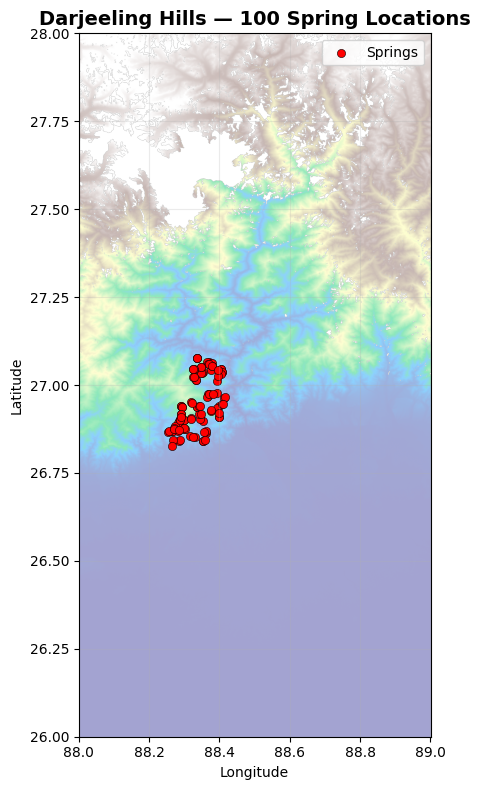

Saved: /content/final_map_1_spring_locations.png


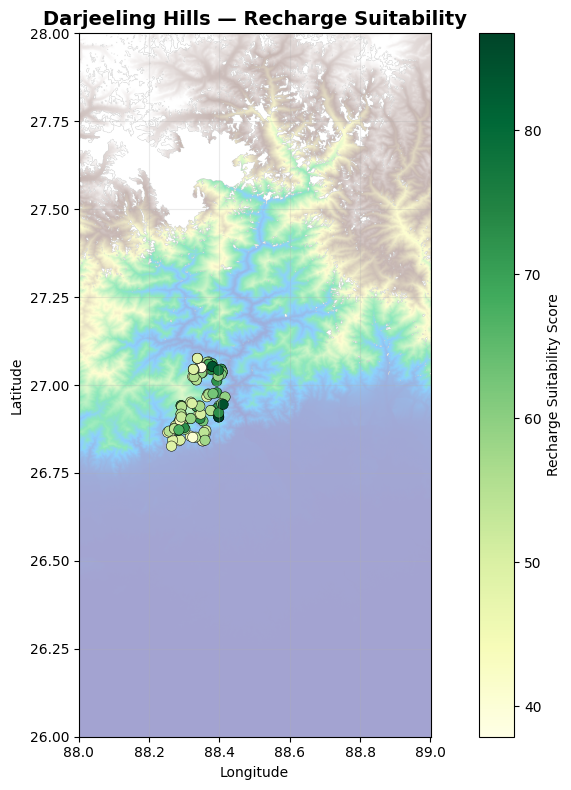

Saved: /content/final_map_2_recharge_suitability.png


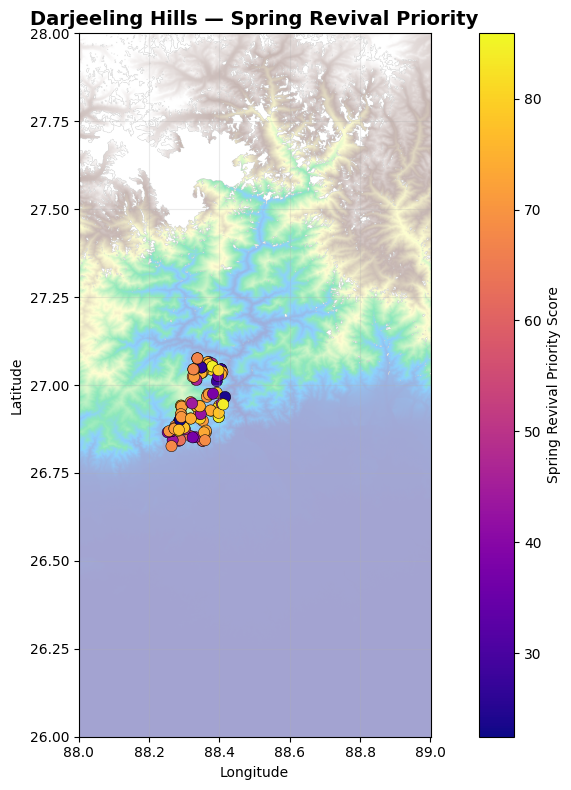

Saved: /content/final_map_3_spring_revival_priority.png


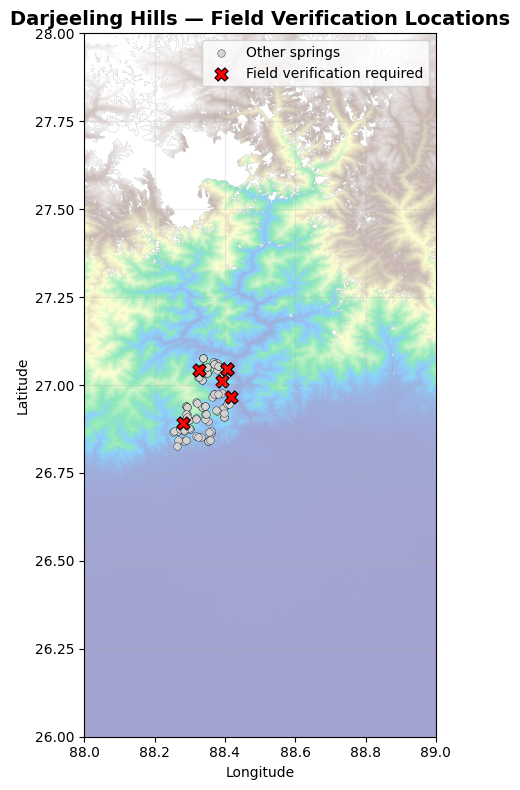

Saved: /content/final_map_4_field_verification.png


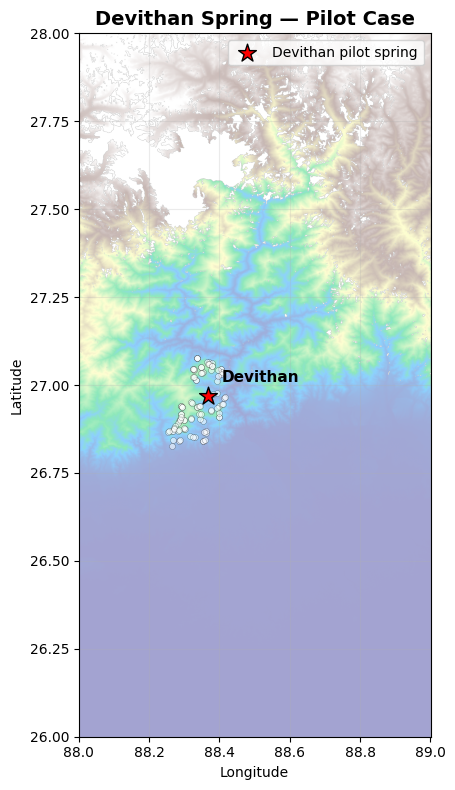

Saved: /content/final_map_5_devithan_pilot.png

FINAL MAP FILES
✅ /content/final_map_1_spring_locations.png
✅ /content/final_map_2_recharge_suitability.png
✅ /content/final_map_3_spring_revival_priority.png
✅ /content/final_map_4_field_verification.png
✅ /content/final_map_5_devithan_pilot.png

✅ CELL 11 COMPLETED


In [12]:
# ============================================================
# CELL 11 — FINAL PROJECT MAPS
# ============================================================

import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import rasterio

# ------------------------------------------------------------
# 1. Find DEM file
# ------------------------------------------------------------

dem_candidates = glob.glob("/content/*darjeeling*merged*dem*.tif")

if len(dem_candidates) == 0:
    raise FileNotFoundError("Darjeeling merged DEM TIFF not found.")

dem_path = dem_candidates[0]

print("Using DEM:")
print(dem_path)

# ------------------------------------------------------------
# 2. Prepare plotting data
# ------------------------------------------------------------

plot_df = priority.copy()

plot_df["Latitude"] = pd.to_numeric(
    plot_df["Latitude"], errors="coerce"
)

plot_df["Longitude"] = pd.to_numeric(
    plot_df["Longitude"], errors="coerce"
)

# ------------------------------------------------------------
# 3. Read DEM
# ------------------------------------------------------------

with rasterio.open(dem_path) as src:
    dem_data = src.read(1).astype(float)
    dem_bounds = src.bounds
    dem_nodata = src.nodata

if dem_nodata is not None:
    dem_data[dem_data == dem_nodata] = np.nan

# Avoid extreme zoom caused by invalid DEM values
valid_dem = dem_data[np.isfinite(dem_data)]

vmin = np.nanpercentile(valid_dem, 2)
vmax = np.nanpercentile(valid_dem, 98)

extent = [
    dem_bounds.left,
    dem_bounds.right,
    dem_bounds.bottom,
    dem_bounds.top
]

# ------------------------------------------------------------
# Helper function for DEM background
# ------------------------------------------------------------

def add_dem(ax):
    ax.imshow(
        dem_data,
        extent=extent,
        origin="upper",
        cmap="terrain",
        vmin=vmin,
        vmax=vmax,
        alpha=0.45
    )

    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.grid(alpha=0.25)


# ============================================================
# MAP 1 — SPRING LOCATIONS
# ============================================================

fig, ax = plt.subplots(figsize=(10, 8))

add_dem(ax)

ax.scatter(
    plot_df["Longitude"],
    plot_df["Latitude"],
    s=35,
    c="red",
    edgecolor="black",
    linewidth=0.4,
    label="Springs"
)

ax.set_title(
    "Darjeeling Hills — 100 Spring Locations",
    fontsize=14,
    fontweight="bold"
)

ax.legend()
plt.tight_layout()

map1 = "/content/final_map_1_spring_locations.png"
plt.savefig(map1, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", map1)


# ============================================================
# MAP 2 — RECHARGE SUITABILITY
# ============================================================

fig, ax = plt.subplots(figsize=(10, 8))

add_dem(ax)

sc = ax.scatter(
    plot_df["Longitude"],
    plot_df["Latitude"],
    c=plot_df["Recharge_Suitability_Score"],
    cmap="YlGn",
    s=55,
    edgecolor="black",
    linewidth=0.35
)

cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("Recharge Suitability Score")

ax.set_title(
    "Darjeeling Hills — Recharge Suitability",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()

map2 = "/content/final_map_2_recharge_suitability.png"
plt.savefig(map2, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", map2)


# ============================================================
# MAP 3 — SPRING REVIVAL PRIORITY
# ============================================================

fig, ax = plt.subplots(figsize=(10, 8))

add_dem(ax)

sc = ax.scatter(
    plot_df["Longitude"],
    plot_df["Latitude"],
    c=plot_df["Spring_Revival_Priority_Score"],
    cmap="plasma",
    s=65,
    edgecolor="black",
    linewidth=0.35
)

cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("Spring Revival Priority Score")

ax.set_title(
    "Darjeeling Hills — Spring Revival Priority",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()

map3 = "/content/final_map_3_spring_revival_priority.png"
plt.savefig(map3, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", map3)


# ============================================================
# MAP 4 — FIELD VERIFICATION REQUIRED
# ============================================================

fig, ax = plt.subplots(figsize=(10, 8))

add_dem(ax)

normal = plot_df[
    plot_df["Final_Status"] !=
    "FIELD_VERIFICATION_REQUIRED"
]

field = plot_df[
    plot_df["Final_Status"] ==
    "FIELD_VERIFICATION_REQUIRED"
]

ax.scatter(
    normal["Longitude"],
    normal["Latitude"],
    s=30,
    c="lightgray",
    edgecolor="black",
    linewidth=0.25,
    label="Other springs"
)

ax.scatter(
    field["Longitude"],
    field["Latitude"],
    s=90,
    c="red",
    marker="X",
    edgecolor="black",
    linewidth=0.8,
    label="Field verification required"
)

ax.set_title(
    "Darjeeling Hills — Field Verification Locations",
    fontsize=14,
    fontweight="bold"
)

ax.legend()
plt.tight_layout()

map4 = "/content/final_map_4_field_verification.png"
plt.savefig(map4, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", map4)


# ============================================================
# MAP 5 — DEVITHAN PILOT CASE
# ============================================================

dev = plot_df[plot_df["Sl_No"] == 1]

fig, ax = plt.subplots(figsize=(9, 8))

add_dem(ax)

ax.scatter(
    plot_df["Longitude"],
    plot_df["Latitude"],
    s=18,
    c="white",
    edgecolor="black",
    linewidth=0.25,
    alpha=0.55
)

ax.scatter(
    dev["Longitude"],
    dev["Latitude"],
    s=180,
    c="red",
    marker="*",
    edgecolor="black",
    linewidth=1.0,
    label="Devithan pilot spring"
)

ax.annotate(
    "Devithan",
    (
        float(dev["Longitude"].iloc[0]),
        float(dev["Latitude"].iloc[0])
    ),
    xytext=(10, 10),
    textcoords="offset points",
    fontsize=11,
    fontweight="bold"
)

ax.set_title(
    "Devithan Spring — Pilot Case",
    fontsize=14,
    fontweight="bold"
)

ax.legend()
plt.tight_layout()

map5 = "/content/final_map_5_devithan_pilot.png"
plt.savefig(map5, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", map5)


# ============================================================
# FINAL OUTPUT CHECK
# ============================================================

print("\n============================================================")
print("FINAL MAP FILES")
print("============================================================")

for f in [map1, map2, map3, map4, map5]:
    print("✅", f)

print("\n✅ CELL 11 COMPLETED")

In [13]:
# ============================================================
# CELL 12 — FINAL PROJECT EXPORT PACKAGE
# ============================================================

import os
import json
import shutil
import numpy as np
import pandas as pd

# ------------------------------------------------------------
# 1. Create final output folder
# ------------------------------------------------------------

output_dir = "/content/SIH26240_Final_Outputs"
os.makedirs(output_dir, exist_ok=True)

print("Output folder:")
print(output_dir)

# ------------------------------------------------------------
# 2. Final master dataset
# ------------------------------------------------------------

master_csv = os.path.join(
    output_dir,
    "darjeeling_final_spring_master_dataset.csv"
)

priority.to_csv(master_csv, index=False)

print("\n✅ Master dataset saved:")
print(master_csv)

# ------------------------------------------------------------
# 3. Point GeoJSON for all 100 springs
# ------------------------------------------------------------

geojson_features = []

# Columns useful for application/dashboard
geo_columns = [
    "Sl_No",
    "Spring Name",
    "State",
    "District",
    "Elevation",
    "Slope",
    "Annual_Rainfall_2023",
    "LULC",
    "Distance_to_Drainage_m",
    "Flow_Accumulation",
    "Clay_0_5cm",
    "Geology",
    "Final_Status",
    "Confidence_Level",
    "Recharge_Suitability_Score",
    "Recharge_Suitability_Class",
    "Indicative_Intervention",
    "Intervention_Category",
    "Risk_Level",
    "Spring_Revival_Priority_Score",
    "Priority_Class",
    "Area_km2",
    "Evidence_Support_Index"
]

for _, row in priority.iterrows():

    properties = {}

    for col in geo_columns:
        value = row[col]

        # Convert pandas/numpy values to JSON-compatible values
        if pd.isna(value):
            properties[col] = None
        elif isinstance(value, (np.integer,)):
            properties[col] = int(value)
        elif isinstance(value, (np.floating,)):
            properties[col] = float(value)
        else:
            properties[col] = value

    feature = {
        "type": "Feature",
        "geometry": {
            "type": "Point",
            "coordinates": [
                float(row["Longitude"]),
                float(row["Latitude"])
            ]
        },
        "properties": properties
    }

    geojson_features.append(feature)

spring_geojson = {
    "type": "FeatureCollection",
    "features": geojson_features
}

geojson_path = os.path.join(
    output_dir,
    "darjeeling_100_springs_final.geojson"
)

with open(geojson_path, "w", encoding="utf-8") as f:
    json.dump(spring_geojson, f, indent=2)

print("\n✅ Spring point GeoJSON saved:")
print(geojson_path)

# ------------------------------------------------------------
# 4. Field-verification GeoJSON
# ------------------------------------------------------------

field_df = priority[
    priority["Final_Status"] ==
    "FIELD_VERIFICATION_REQUIRED"
].copy()

field_features = []

for _, row in field_df.iterrows():

    properties = {
        "Sl_No": int(row["Sl_No"]),
        "Spring_Name": str(row["Spring Name"]),
        "Suitability_Score": float(
            row["Recharge_Suitability_Score"]
        ),
        "Risk_Level": str(row["Risk_Level"]),
        "Priority_Score": float(
            row["Spring_Revival_Priority_Score"]
        )
    }

    field_features.append({
        "type": "Feature",
        "geometry": {
            "type": "Point",
            "coordinates": [
                float(row["Longitude"]),
                float(row["Latitude"])
            ]
        },
        "properties": properties
    })

field_geojson = {
    "type": "FeatureCollection",
    "features": field_features
}

field_geojson_path = os.path.join(
    output_dir,
    "field_verification_springs.geojson"
)

with open(field_geojson_path, "w", encoding="utf-8") as f:
    json.dump(field_geojson, f, indent=2)

print("\n✅ Field verification GeoJSON saved:")
print(field_geojson_path)

# ------------------------------------------------------------
# 5. Top-15 priority GeoJSON
# ------------------------------------------------------------

top15_df = (
    priority
    .sort_values(
        "Spring_Revival_Priority_Score",
        ascending=False
    )
    .head(15)
)

top_features = []

for _, row in top15_df.iterrows():

    top_features.append({
        "type": "Feature",
        "geometry": {
            "type": "Point",
            "coordinates": [
                float(row["Longitude"]),
                float(row["Latitude"])
            ]
        },
        "properties": {
            "Sl_No": int(row["Sl_No"]),
            "Spring_Name": str(row["Spring Name"]),
            "Priority_Score": float(
                row["Spring_Revival_Priority_Score"]
            ),
            "Priority_Class": str(row["Priority_Class"]),
            "Suitability_Score": float(
                row["Recharge_Suitability_Score"]
            ),
            "Suitability_Class": str(
                row["Recharge_Suitability_Class"]
            ),
            "Intervention": str(
                row["Indicative_Intervention"]
            )
        }
    })

top_geojson = {
    "type": "FeatureCollection",
    "features": top_features
}

top_geojson_path = os.path.join(
    output_dir,
    "top_15_priority_springs.geojson"
)

with open(top_geojson_path, "w", encoding="utf-8") as f:
    json.dump(top_geojson, f, indent=2)

print("\n✅ Top-15 GeoJSON saved:")
print(top_geojson_path)

# ------------------------------------------------------------
# 6. Project summary JSON
# ------------------------------------------------------------

project_summary = {
    "project_id": "SIH26240",
    "pilot_region": "Darjeeling Hills, West Bengal",
    "total_springs": int(len(priority)),
    "primary_zones": int(
        (priority["Final_Status"] == "PRIMARY_ZONE").sum()
    ),
    "lower_confidence_zones": int(
        (
            priority["Final_Status"] ==
            "LOWER_CONFIDENCE_ZONE"
        ).sum()
    ),
    "field_verification_required": int(
        (
            priority["Final_Status"] ==
            "FIELD_VERIFICATION_REQUIRED"
        ).sum()
    ),
    "model_derived_zones": int(
        (priority["Area_km2"].fillna(0) > 0).sum()
    ),
    "total_zone_area_km2": float(
        priority["Area_km2"].fillna(0).sum()
    ),
    "mean_suitability_score": float(
        priority["Recharge_Suitability_Score"].mean()
    ),
    "mean_priority_score": float(
        priority["Spring_Revival_Priority_Score"].mean()
    ),
    "suitability_classes": {
        str(k): int(v)
        for k, v in
        priority["Recharge_Suitability_Class"]
        .value_counts()
        .items()
    },
    "risk_levels": {
        str(k): int(v)
        for k, v in
        priority["Risk_Level"]
        .value_counts()
        .items()
    },
    "priority_classes": {
        str(k): int(v)
        for k, v in
        priority["Priority_Class"]
        .value_counts()
        .items()
    },
    "note": (
        "Recharge suitability and priority are pilot "
        "decision-support indices. They are not direct "
        "measurements of groundwater recharge probability. "
        "Field verification is required for unresolved or "
        "site-sensitive locations."
    )
}

summary_json = os.path.join(
    output_dir,
    "project_summary.json"
)

with open(summary_json, "w", encoding="utf-8") as f:
    json.dump(project_summary, f, indent=2)

print("\n✅ Project summary JSON saved:")
print(summary_json)

# ------------------------------------------------------------
# 7. Copy final maps
# ------------------------------------------------------------

map_files = [
    "/content/final_map_1_spring_locations.png",
    "/content/final_map_2_recharge_suitability.png",
    "/content/final_map_3_spring_revival_priority.png",
    "/content/final_map_4_field_verification.png",
    "/content/final_map_5_devithan_pilot.png"
]

print("\n================ COPY FINAL MAPS ================\n")

for map_file in map_files:

    if os.path.exists(map_file):

        destination = os.path.join(
            output_dir,
            os.path.basename(map_file)
        )

        shutil.copy2(map_file, destination)

        print("✅", os.path.basename(map_file))

    else:
        print("⚠️ Missing:", map_file)

# ------------------------------------------------------------
# 8. Copy summary CSVs
# ------------------------------------------------------------

summary_files = [
    "/content/final_project_summary.csv",
    "/content/top_15_priority_springs.csv",
    "/content/field_verification_springs.csv"
]

print("\n================ COPY SUMMARY CSVs ================\n")

for csv_file in summary_files:

    if os.path.exists(csv_file):

        destination = os.path.join(
            output_dir,
            os.path.basename(csv_file)
        )

        shutil.copy2(csv_file, destination)

        print("✅", os.path.basename(csv_file))

# ------------------------------------------------------------
# 9. Final package listing
# ------------------------------------------------------------

print("\n============================================================")
print("FINAL PROJECT OUTPUT PACKAGE")
print("============================================================")

for name in sorted(os.listdir(output_dir)):
    print("✅", name)

print("\n============================================================")
print("✅ CELL 12 COMPLETED")
print("============================================================")

Output folder:
/content/SIH26240_Final_Outputs

✅ Master dataset saved:
/content/SIH26240_Final_Outputs/darjeeling_final_spring_master_dataset.csv

✅ Spring point GeoJSON saved:
/content/SIH26240_Final_Outputs/darjeeling_100_springs_final.geojson

✅ Field verification GeoJSON saved:
/content/SIH26240_Final_Outputs/field_verification_springs.geojson

✅ Top-15 GeoJSON saved:
/content/SIH26240_Final_Outputs/top_15_priority_springs.geojson

✅ Project summary JSON saved:
/content/SIH26240_Final_Outputs/project_summary.json

================ COPY FINAL MAPS ================

✅ final_map_1_spring_locations.png
✅ final_map_2_recharge_suitability.png
✅ final_map_3_spring_revival_priority.png
✅ final_map_4_field_verification.png
✅ final_map_5_devithan_pilot.png

================ COPY SUMMARY CSVs ================

✅ final_project_summary.csv
✅ top_15_priority_springs.csv
✅ field_verification_springs.csv

FINAL PROJECT OUTPUT PACKAGE
✅ darjeeling_100_springs_final.geojson
✅ darjeeling_final_sprin

In [ ]:
# SIH26240 — AI-Based Spring Revival and Recharge Planning
## Final Darjeeling Hills Pilot — Methodology & Documentation

### 1. Project Objective

The system provides an AI/GIS-enabled decision-support workflow for identifying
probable spring influence/recharge zones and prioritizing spring-revival
interventions for the Darjeeling Hills pilot region of West Bengal.

The system combines spring observations with terrain, drainage, rainfall,
land-use/land-cover, soil, and geological information.

---

### 2. Pilot Dataset

Pilot Region:
Darjeeling Hills, West Bengal

Number of springs:
100

Primary input datasets:

- Spring inventory and field attributes
- SRTM Digital Elevation Model (DEM)
- DEM-derived slope and aspect
- Drainage and flow-accumulation information
- IMD 2023 rainfall data
- ESA WorldCover 2021 LULC
- SoilGrids clay content
- Geological information from available geological maps/sources
- CGWB 32-spring discharge dataset for pilot feature/model exploration

---

### 3. Processing Workflow

REAL DATA
↓
GIS PROCESSING
↓
FEATURE ENGINEERING
↓
PROBABLE SPRING INFLUENCE / RECHARGE ZONE ANALYSIS
↓
EVIDENCE SUPPORT
↓
RECHARGE SUITABILITY INDEX
↓
INTERVENTION SCREENING
↓
RISK ASSESSMENT
↓
SPRING REVIVAL PRIORITY
↓
FIELD VERIFICATION
↓
FUTURE FEEDBACK / MODEL IMPROVEMENT

---

### 4. Final Zone Classification

The final 100-spring analysis produced:

- 88 PRIMARY_ZONE
- 6 LOWER_CONFIDENCE_ZONE
- 6 FIELD_VERIFICATION_REQUIRED

Model-derived zones were available for 94 springs.

Total model-derived zone area:
111.0393 km²

The zone outputs represent model-derived probable influence/recharge
candidate areas and should not be interpreted as exact groundwater recharge
boundaries.

---

### 5. Recharge Suitability

The final pilot suitability index combines:

- Flow accumulation
- Distance to drainage
- Rainfall
- Soil clay content
- Slope preference
- Geological suitability
- LULC suitability

Final suitability classes:

- High: 19 springs
- Moderate: 78 springs
- Low: 3 springs

Mean suitability score:
58.2239

---

### 6. Intervention Screening

The system provides indicative intervention categories based on the combined
spatial indicators and final spring classification.

Final intervention categories:

- Site-specific Assessment: 61
- Contour / Infiltration: 20
- Drainage-line Recharge: 11
- Field Verification: 6
- Detailed Assessment: 2

These are screening-level recommendations and are not engineering designs.

---

### 7. Risk Assessment

The system considers:

- Steep terrain
- Lower-confidence zones
- Low suitability
- Field-verification requirements

Final risk levels:

- Low: 75
- Moderate: 5
- High: 20

---

### 8. Spring Revival Priority

Priority is calculated from:

- Recharge suitability
- Evidence support
- Confidence level
- Risk adjustment

Final priority classes:

- Higher Priority: 74
- Moderate Priority: 10
- Lower Priority: 16

Mean priority score:
63.7211

---

### 9. Devithan Pilot Case

Pilot spring:
Devithan
Sl_No: 1

Latitude:
26.969786

Longitude:
88.366003

Final status:
PRIMARY_ZONE

Confidence:
Higher

Model-derived zone area:
0.9396 km²

Evidence Support Index:
0.824904

Recharge suitability:
58.751083

Suitability class:
Moderate

Priority score:
74.122668

Priority class:
Higher Priority

Indicative intervention:
Site-specific recharge assessment

Risk level:
Low

---

### 10. Important Modelling Limitation

The present system is a pilot GIS/rule-based decision-support framework.

The current suitability and priority scores are indices and should not be
described as direct measurements of groundwater recharge probability.

Similarly, the model-derived influence/recharge zones are probable candidate
areas rather than exact subsurface groundwater recharge boundaries.

Field verification and discharge observations are required before engineering
implementation.

---

### 11. Machine Learning Experiment

A separate 32-spring CGWB dataset was used for pilot discharge prediction and
feature exploration.

This experiment is treated as a validation/feature-exploration component and
is not used as the main recharge-zone model.

The current project therefore does not claim a universally trained
groundwater-recharge prediction model.

---

### 12. Final Export Package

The final project package contains:

- Final master spring dataset
- Spring point GeoJSON
- Field-verification GeoJSON
- Top-15 priority spring GeoJSON
- Project summary JSON
- Final maps
- Final project summary CSV
- Top-15 priority spring CSV
- Field-verification CSV

---

### 13. Future Scope

Future development can include:

- Multi-region training and validation
- More spring discharge observations
- Seasonal and multi-year rainfall trends
- Improved geological structural data
- Community/field observations
- Field-verified recharge boundaries
- Feedback-based model updating
- Interactive GIS dashboard
- Backend/API integration
- Addition of future sensor observations

---

### 14. Final Interpretation

The system should be presented as an AI/GIS-enabled decision-support system
that combines heterogeneous geospatial evidence to support spring-revival
planning.

It should not be presented as a system that directly observes or guarantees
subsurface groundwater recharge zones.

In [15]:
# ============================================================
# CELL 14 — CREATE FINAL PROJECT ZIP PACKAGE
# ============================================================

import os
import shutil

# Final output folder
output_dir = "/content/SIH26240_Final_Outputs"

# ZIP destination
zip_base = "/content/SIH26240_Spring_Revival_Final"

# Remove old ZIP base if it already exists
if os.path.exists(zip_base + ".zip"):
    os.remove(zip_base + ".zip")

# Create ZIP
zip_path = shutil.make_archive(
    zip_base,
    "zip",
    output_dir
)

print("============================================================")
print("FINAL ZIP PACKAGE")
print("============================================================")

print("\n✅ ZIP created successfully:")
print(zip_path)

# File size
size_mb = os.path.getsize(zip_path) / (1024 * 1024)

print(f"\nZIP size: {size_mb:.2f} MB")

# Verify ZIP contents
import zipfile

with zipfile.ZipFile(zip_path, "r") as z:
    files_in_zip = z.namelist()

print("\nFiles inside ZIP:")
for f in files_in_zip:
    print("✅", f)

print("\n============================================================")
print("✅ CELL 14 COMPLETED")
print("============================================================")

FINAL ZIP PACKAGE

✅ ZIP created successfully:
/content/SIH26240_Spring_Revival_Final.zip

ZIP size: 8.12 MB

Files inside ZIP:
✅ final_project_summary.csv
✅ final_map_3_spring_revival_priority.png
✅ final_map_5_devithan_pilot.png
✅ final_map_4_field_verification.png
✅ top_15_priority_springs.csv
✅ field_verification_springs.csv
✅ project_summary.json
✅ final_map_1_spring_locations.png
✅ darjeeling_final_spring_master_dataset.csv
✅ top_15_priority_springs.geojson
✅ final_map_2_recharge_suitability.png
✅ field_verification_springs.geojson
✅ darjeeling_100_springs_final.geojson

✅ CELL 14 COMPLETED


In [16]:
# ============================================================
# CELL 15 — FINAL README + REBUILD ZIP
# ============================================================

import os
import shutil

output_dir = "/content/SIH26240_Final_Outputs"

readme_text = """
SIH26240 — AI-Based Spring Revival and Recharge Planning
=========================================================

Pilot Region:
Darjeeling Hills, West Bengal

PROJECT OVERVIEW
----------------
This project is a GIS/AI-enabled decision-support workflow for spring
revival and probable recharge/influence-zone planning.

The system integrates spring observations with:
- Digital Elevation Model (DEM)
- Slope and terrain indicators
- Drainage and flow accumulation
- Rainfall
- Land Use / Land Cover
- Soil clay content
- Geological information

FINAL PILOT RESULTS
-------------------
Total springs: 100
Primary zones: 88
Lower-confidence zones: 6
Field verification required: 6
Model-derived zones: 94
Total model-derived zone area: 111.0393 km²

Recharge suitability:
- High: 19
- Moderate: 78
- Low: 3

Risk:
- Low: 75
- Moderate: 5
- High: 20

Spring revival priority:
- Higher Priority: 74
- Moderate Priority: 10
- Lower Priority: 16

IMPORTANT INTERPRETATION
------------------------
The recharge suitability and spring-revival priority scores are pilot
decision-support indices.

The model-derived zones represent probable candidate influence/recharge
areas and must NOT be interpreted as exact subsurface groundwater
recharge boundaries.

Field verification and hydrological/discharge observations are required
before engineering implementation.

FILES
-----
darjeeling_final_spring_master_dataset.csv
    Complete final dataset for all 100 springs.

darjeeling_100_springs_final.geojson
    Point GeoJSON containing the 100 springs and major model attributes.

field_verification_springs.geojson
    Point GeoJSON for the six springs requiring field verification.

top_15_priority_springs.geojson
    Point GeoJSON for the 15 highest priority records.

final_project_summary.csv
    Main project statistics.

top_15_priority_springs.csv
    Tabular top-15 priority list.

field_verification_springs.csv
    Tabular field-verification list.

project_summary.json
    Machine-readable project summary.

FINAL MAPS
----------
final_map_1_spring_locations.png
final_map_2_recharge_suitability.png
final_map_3_spring_revival_priority.png
final_map_4_field_verification.png
final_map_5_devithan_pilot.png

DEVITHAN PILOT
--------------
Spring: Devithan
Sl_No: 1
Latitude: 26.969786
Longitude: 88.366003
Status: PRIMARY_ZONE
Confidence: Higher
Zone area: 0.9396 km²
Evidence Support Index: 0.824904
Suitability score: 58.751083
Priority score: 74.122668
Priority class: Higher Priority

NOTE
----
This final export package contains point-based GeoJSON outputs.
Exact recharge-zone polygon GeoJSON geometry is not included because
such geometry was not available as a verified final exported artifact.
No polygon geometry has been fabricated.
"""

readme_path = os.path.join(output_dir, "README.md")

with open(readme_path, "w", encoding="utf-8") as f:
    f.write(readme_text.strip())

print("✅ README created:")
print(readme_path)

# ------------------------------------------------------------
# Rebuild ZIP so README is included
# ------------------------------------------------------------

zip_base = "/content/SIH26240_Spring_Revival_Final"

if os.path.exists(zip_base + ".zip"):
    os.remove(zip_base + ".zip")

zip_path = shutil.make_archive(
    zip_base,
    "zip",
    output_dir
)

print("\n✅ ZIP rebuilt:")
print(zip_path)

size_mb = os.path.getsize(zip_path) / (1024 * 1024)

print(f"ZIP size: {size_mb:.2f} MB")

print("\n============================================================")
print("FINAL PACKAGE READY")
print("============================================================")

✅ README created:
/content/SIH26240_Final_Outputs/README.md

✅ ZIP rebuilt:
/content/SIH26240_Spring_Revival_Final.zip
ZIP size: 8.12 MB

FINAL PACKAGE READY
